In [26]:
# Question 1
import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np

#Load dataset
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X_original = iris.data
y = iris.target

# New feature definitions
nf1 = X_original[:, 0]*X_original[:, 1]
nf2 = X_original[:, 2]*X_original[:, 2]

# New Dataset Definition
New = np.column_stack((nf1, nf2))


#split into input (X) and output (y)
from sklearn.model_selection import train_test_split
New_train, New_test, y_train, y_test = train_test_split(New, y,
test_size=0.4, random_state=123, shuffle=True,stratify=y)

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train SVM classifier
svm_model = SVC()
svm_model.fit(New_train, y_train)

# Make predictions and calculate accuracy
y_pred = svm_model.predict(New_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the SVM classifier: {accuracy}")

Accuracy of the SVM classifier: 0.95


First 10 labels: [0 4 2 4 6 2 8 6 4 0]
Shape: (34418, 784)


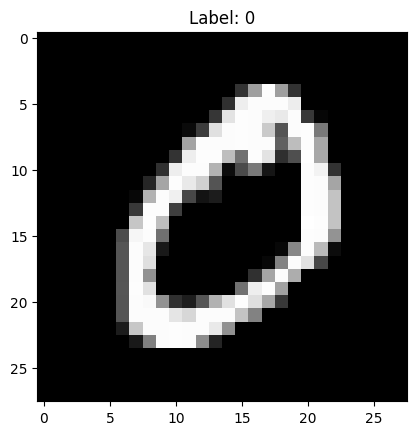

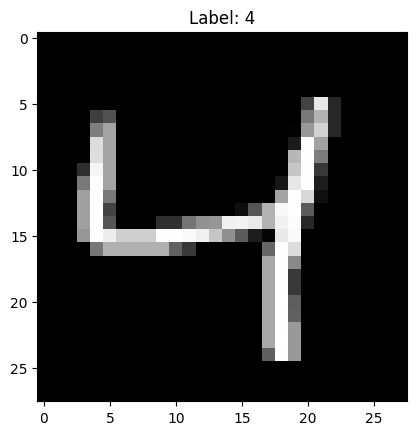

Training set shape: (27534, 784)
Test set shape: (6884, 784)


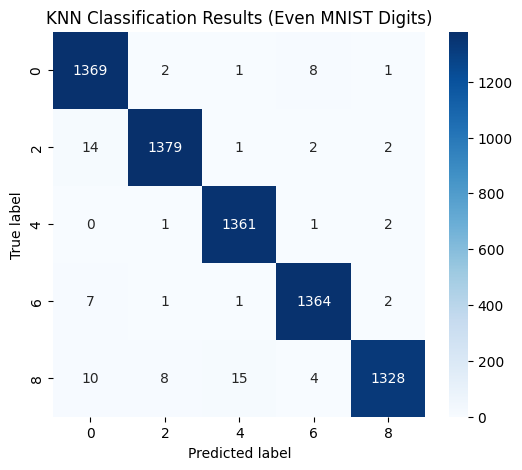

Number of 6's correctly classified: 1364
Pairplot cannot be used to visualize this data as this is a higher dimensional dataset than the iris data which only has 4 features
MNIST images are 28 x 28 arrays so there is too much information present to show using pairplot comparisons


In [27]:
# Question 2
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load MNIST Dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

# get rid of odds
even_mask = y % 2 == 0
X_even = X[even_mask]
y_even = y[even_mask]

# Convert to NumPy arrays for clean indexing
X_even = X_even.to_numpy()
y_even = y_even.to_numpy()

# Now you can safely do:
print("First 10 labels:", y_even[:10])
print("Shape:", X_even.shape)

# Visualize first 2 images
import matplotlib.pyplot as plt

for i in range(2):
    plt.imshow(X_even[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_even[i]}")
    plt.show()

from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_even, y_even, test_size=0.2, random_state=123, stratify=y_even
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Train KNN
from sklearn.neighbors import KNeighborsClassifier

# KNN classifier with k=3 (can be adjusted)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

#Plotting
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for even digits only
labels = [0,2,4,6,8]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("KNN Classification Results (Even MNIST Digits)")
plt.show()

correct_6 = cm[3,3]
print("Number of 6's correctly classified:", correct_6)

#Can pairplot be used?
print("Pairplot cannot be used to visualize this data as this is a higher dimensional dataset than the iris data which only has 4 features")
print("MNIST images are 28 x 28 arrays so there is too much information present to show using pairplot comparisons")


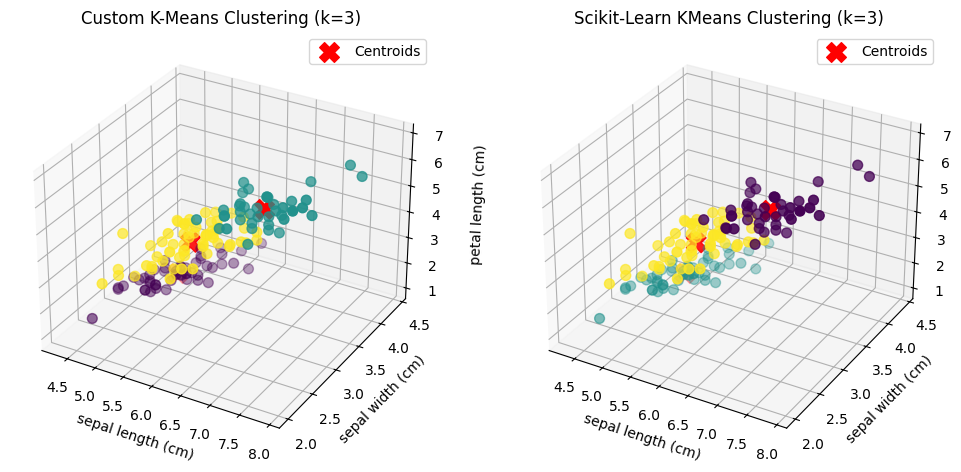

In [28]:
#Question 3
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load iris dataset
iris = datasets.load_iris()
X = iris.data[:, :3]
y = iris.target

# K-means algorithm
def kmeans(X, k, max_iters=100, random_state=123):
    np.random.seed(random_state)
    rand_indices = np.random.choice(len(X), k, replace=False)
    centroids = X[rand_indices]
    for _ in range(max_iters):
      distances = np.linalg.norm(X[:, np.newaxis, :] - centroids, axis=2)
      labels = np.argmin(distances, axis=1)
      new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
      if np.allclose(centroids, new_centroids):
          break
      centroids = new_centroids
    return labels, new_centroids

# Create a figure with a smaller figure size
fig = plt.figure(figsize=(12, 6))

# Run your K-means and plot on the left subplot by manually setting position
labels, centroids = kmeans(X, k=3)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X[:,0], X[:,1], X[:,2], c=labels, cmap='viridis', s=50)
ax1.scatter(centroids[:,0], centroids[:,1], centroids[:,2],
           c='red', marker='X', s=200, label='Centroids')
ax1.set_xlabel(iris.feature_names[0])
ax1.set_ylabel(iris.feature_names[1])
ax1.set_zlabel(iris.feature_names[2], labelpad=10) # Added labelpad
ax1.set_title('Custom K-Means Clustering (k=3)')
ax1.legend()

# Scikit-Learn K-means and plot on the right subplot by manually setting position
from sklearn.cluster import KMeans
kmeans_sklearn = KMeans(n_clusters=3, random_state=123, n_init=10)
labels_sklearn = kmeans_sklearn.fit_predict(X)
centroids_sklearn = kmeans_sklearn.cluster_centers_

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(X[:,0], X[:,1], X[:,2], c=labels_sklearn, cmap='viridis', s=50)
ax2.scatter(centroids_sklearn[:,0], centroids_sklearn[:,1], centroids_sklearn[:,2],
           c='red', marker='X', s=200, label='Centroids')
ax2.set_xlabel(iris.feature_names[0])
ax2.set_ylabel(iris.feature_names[1])
ax2.set_zlabel(iris.feature_names[2], labelpad=10) # Added labelpad
ax2.set_title('Scikit-Learn KMeans Clustering (k=3)')
ax2.legend()

# Adjust layout to prevent labels from being cut off
# Use fig.subplots_adjust() for more fine-grained control
# fig.subplots_adjust(left=0.05, right=0.8, bottom=0.05, top=0.95, wspace=0.4, hspace=0.2) # Adjusted right and wspace
# plt.tight_layout(pad=3.0) # Commented out tight_layout

plt.show()

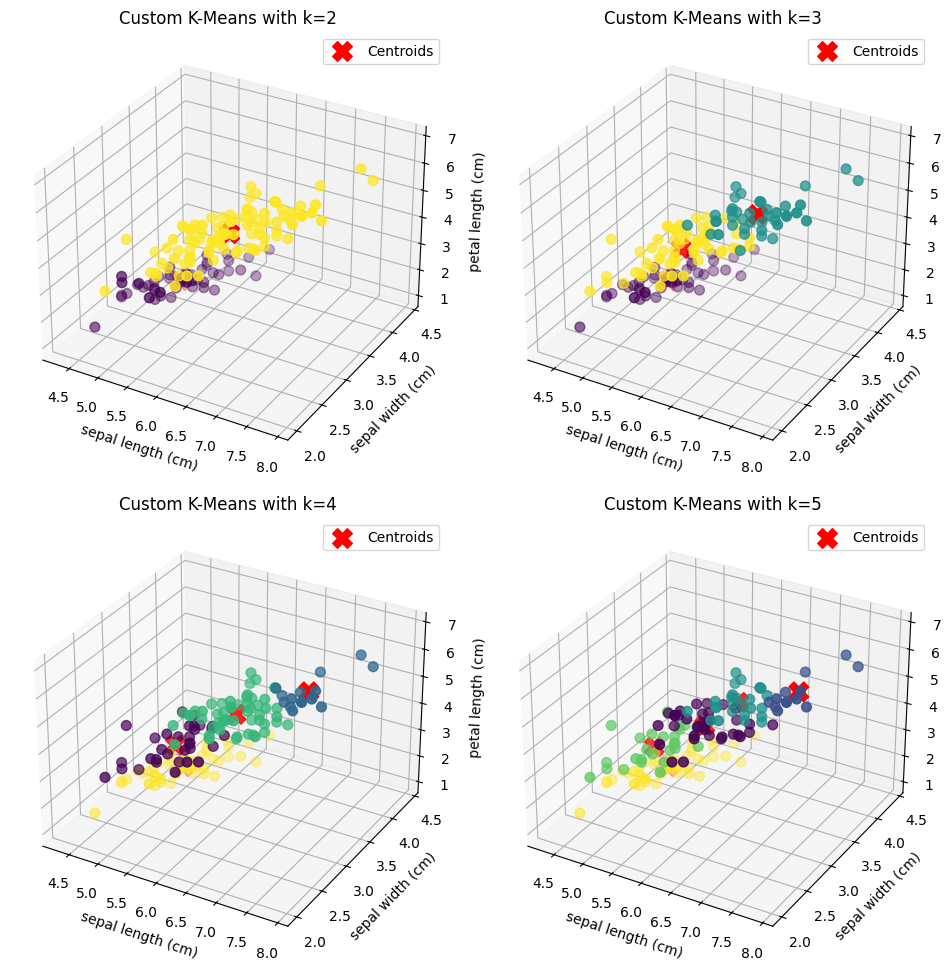

In [29]:
# Varying k and plotting all on a single figure
num_k_values = len([2, 3, 4, 5])
# Determine the grid size for subplots (e.g., 2x2 for 4 plots)
n_cols = 2
n_rows = (num_k_values + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 5),
                         subplot_kw={'projection': '3d'})
axes = axes.flatten() # Flatten the axes array for easy iteration

for i, k in enumerate([2, 3, 4, 5]):
    labels_varied, centroids_varied = kmeans(X, k=k)
    ax = axes[i]
    ax.scatter(X[:,0], X[:,1], X[:,2], c=labels_varied, cmap='viridis', s=50)
    ax.scatter(centroids_varied[:,0], centroids_varied[:,1], centroids_varied[:,2],
               c='red', marker='X', s=200, label='Centroids')
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.set_zlabel(iris.feature_names[2])

    ax.set_title(f'Custom K-Means with k={k}')
    ax.legend()

# Hide any unused subplots
for j in range(num_k_values, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.show()